<a href="https://colab.research.google.com/github/sbajnaid/Lab-4/blob/main/ML_Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [2]:
df = pd.read_csv("/[Lab 2] Pass-Fail Data.csv")

In [3]:
df.head()

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,12,1
1,2,88,85,79,10,1
2,3,60,55,58,4,0
3,4,72,70,65,6,1
4,5,40,45,50,3,0


In [5]:
df.dtypes

,0
student_id,int64
attendance_pct,int64
homework_pct,int64
midterm_score,int64
study_hours_per_week,int64
pass,int64


In [7]:
df.isna()

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
95,False,False,False,False,False,False
96,False,False,False,False,False,False
97,False,False,False,False,False,False
98,False,False,False,False,False,False


In [8]:
df.isna().sum()

,0
student_id,0
attendance_pct,0
homework_pct,0
midterm_score,0
study_hours_per_week,0
pass,0


Task 1: There are no data quality issues in this data set. All the variables have the appropriate data type, and there are no missing values or records.

In [9]:
#creating missing values in the 'study_hours_per_week' feature
df2 = df.copy()
df2.loc[0:5, 'study_hours_per_week'] = np.nan

In [10]:
df2.isna().sum()

,0
student_id,0
attendance_pct,0
homework_pct,0
midterm_score,0
study_hours_per_week,6
pass,0


In [11]:
df2.head(10)

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,NaN,1
1,2,88,85,79,NaN,1
2,3,60,55,58,NaN,0
3,4,72,70,65,NaN,1
4,5,40,45,50,NaN,0
5,6,85,90,91,NaN,1
6,7,78,80,74,8.0,1
7,8,55,60,62,5.0,0
8,9,90,88,84,11.0,1
9,10,68,65,60,6.0,1


In [14]:
#performing mean imputation to handle the missing values
df_mean = df2.copy()
df_mean['study_hours_per_week'].fillna(df_mean['study_hours_per_week'].mean(), inplace=True)

/tmp/ipykernel_3811/623919601.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mean['study_hours_per_week'].fillna(df_mean['study_hours_per_week'].mean(), inplace=True)


Task 2: Choosing strategy 2, mean imputation, to deal with the missing values because this data set only has 100 records (so deleting the records could reduce performance) and because there are no noticeable outliers in this feature.

In [15]:
df_mean.head(10)

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,7.223404,1
1,2,88,85,79,7.223404,1
2,3,60,55,58,7.223404,0
3,4,72,70,65,7.223404,1
4,5,40,45,50,7.223404,0
5,6,85,90,91,7.223404,1
6,7,78,80,74,8.000000,1
7,8,55,60,62,5.000000,0
8,9,90,88,84,11.000000,1
9,10,68,65,60,6.000000,1


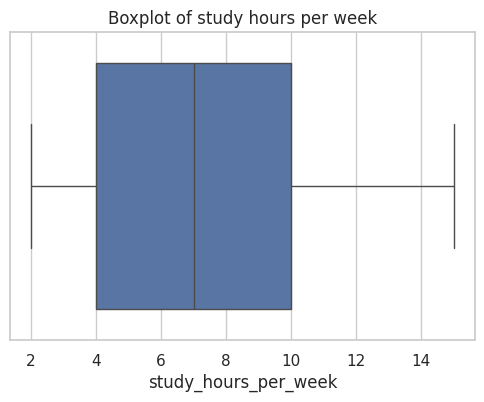

In [17]:
#plotting a boxplot to check the existence of outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df['study_hours_per_week'])

plt.title('Boxplot of study hours per week')
plt.show()

In [27]:
#calculating the IQR to detect outliers
Q1 = df['study_hours_per_week'].quantile(0.25)
Q3 = df['study_hours_per_week'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['study_hours_per_week'] < lower) | (df['study_hours_per_week'] > upper)]
outliers.head(15)

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass


In [28]:
#removing outliers that fall outside of an acceptable range
df_no_outliers = df[(df['study_hours_per_week'] >= lower) & (df['study_hours_per_week'] <= upper)]

print('df with outliers: ',df.shape)
print('df without outliers: ',df_no_outliers.shape)

df with outliers:  (100, 6)
df without outliers:  (100, 6)


Task 3: From the boxplot, no outliers can be seen since there aren't any data points outside the whiskers. The table calculating the IQR did not display any records, further proving that there are no outliers. Finally, the size of the data set did not change when the outliers were 'removed'.

In [29]:
df[['student_id','attendance_pct','homework_pct','midterm_score','study_hours_per_week']].head()

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week
0,1,95,92,88,12
1,2,88,85,79,10
2,3,60,55,58,4
3,4,72,70,65,6
4,5,40,45,50,3


In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['student_id','attendance_pct','homework_pct','midterm_score','study_hours_per_week']].copy()

df_scaled[['student_id','attendance_pct','homework_pct','midterm_score','study_hours_per_week']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week
0,0.000000,1.000000,0.934426,0.836364,0.769231
1,0.010101,0.892308,0.819672,0.672727,0.615385
2,0.020202,0.461538,0.327869,0.290909,0.153846
3,0.030303,0.646154,0.573770,0.418182,0.307692
4,0.040404,0.153846,0.163934,0.145455,0.076923


Task 4: Min-max normalization. Did not include 'Pass' because it's the target variable.

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['student_id','attendance_pct','homework_pct','midterm_score','study_hours_per_week']].copy()

df_standardized[['student_id','attendance_pct','homework_pct','midterm_score','study_hours_per_week']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week
0,-1.714816,1.450752,1.356943,1.312529,1.310020
1,-1.680173,1.052194,0.943421,0.697921,0.754927
2,-1.645531,-0.542039,-0.828816,-0.736164,-0.910353
3,-1.610888,0.141204,0.057302,-0.258135,-0.355260
4,-1.576245,-1.680777,-1.419562,-1.282482,-1.187899


Task 4: Z-score normalization.

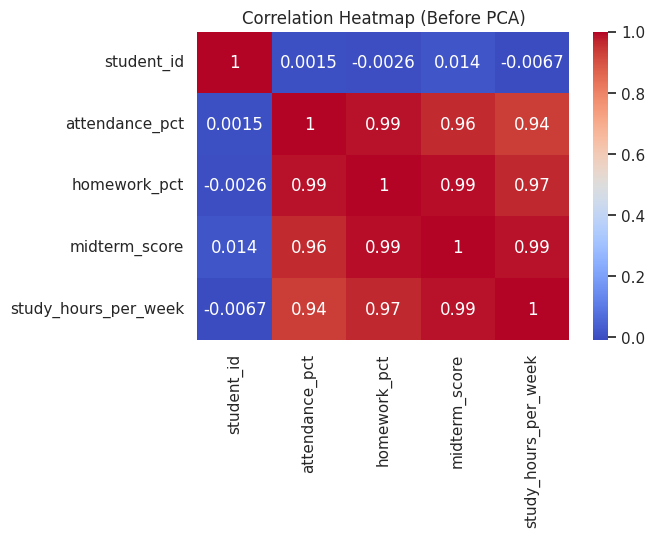

In [32]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['student_id','attendance_pct','homework_pct','midterm_score','study_hours_per_week']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

Task 5: There is a strong positive correlation between all the variables, except for the correlation with student id. This makes sense because the student id is an incremented number and it has no correlation with performance. We can therefore apply the PCA without considering the student id.

In [40]:
from sklearn.decomposition import PCA

X = df_standardized[['attendance_pct','homework_pct','midterm_score','study_hours_per_week']]

pca = PCA(n_components=4)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [9.78550237e-01 1.77458046e-02 2.80397950e-03 8.99978448e-04]


/usr/local/lib/python3.12/dist-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


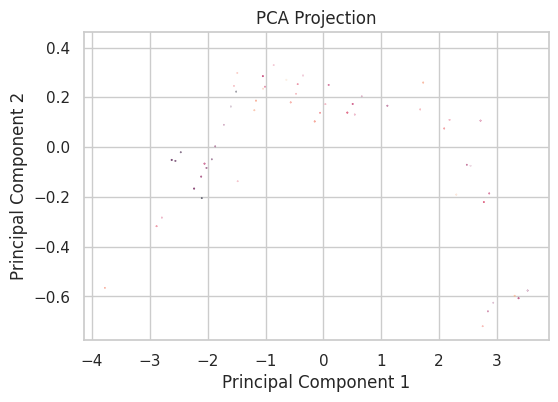

In [41]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1], principal_components[:,2], principal_components[:,3])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Result of the PCA without the student id.